# Multiple Testing — An Illustrated Tour

> Inspired by **ISLR Ch. 13**.

Run $m$ independent hypothesis tests at level $\alpha = 0.05$ on data where **all nulls are true** — and you'll still get $\approx 0.05 m$ rejections by pure chance. We need new error rates and procedures.

| Quantity | Definition |
|---|---|
| FWER | $\Pr(\text{at least one false rejection})$ |
| FDR | $\mathbb{E}\bigl[\text{false rejections} / \text{total rejections}\bigr]$ |
| Bonferroni | reject if $p_i < \alpha/m$ — controls FWER |
| Benjamini–Hochberg | reject if $p_{(i)} < (i/m)\,\alpha$ — controls FDR |


## The picture — p-value histogram: uniform under null + a spike near 0 from true signals

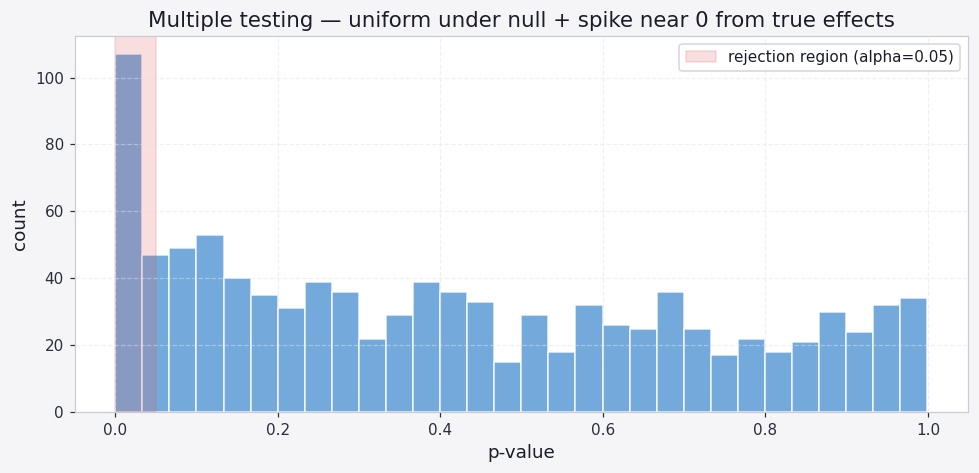

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
p_null = rng.uniform(0, 1, 800); p_alt = rng.beta(0.5, 5, 200)
ps = np.concatenate([p_null, p_alt])
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.hist(ps, bins=30, color=P[0], edgecolor='white', alpha=0.85)
ax.axvspan(0, 0.05, color=P[1], alpha=0.20, label='rejection region (alpha=0.05)')
ax.set_xlabel('p-value'); ax.set_ylabel('count')
ax.set_title('Multiple testing — uniform under null + spike near 0 from true effects')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

from scipy import stats

rng = np.random.RandomState(0)
m = 500
n_per = 30
n_signal = 50            # first 50 features have a real effect
true_signal = np.zeros(m, dtype=bool); true_signal[:n_signal] = True

# simulate: signal features have a real shift, others are pure null
X1 = rng.randn(n_per, m)
X2 = rng.randn(n_per, m)
X1[:, :n_signal] += 1.0   # effect size 1.0 σ

pvals = np.array([stats.ttest_ind(X1[:, j], X2[:, j]).pvalue for j in range(m)])
print(f'{m} tests; {n_signal} truly non-null')
print(f'  raw rejections at α=0.05: {(pvals < 0.05).sum()}')
print(f'  expected raw type-I errors under H0: {0.05 * (m - n_signal):.0f}')


500 tests; 50 truly non-null
  raw rejections at α=0.05: 69
  expected raw type-I errors under H0: 22


---
## 1. p-value histogram — the diagnostic plot

Under $H_0$, p-values are **uniform**. A spike near 0 is your signal pile.


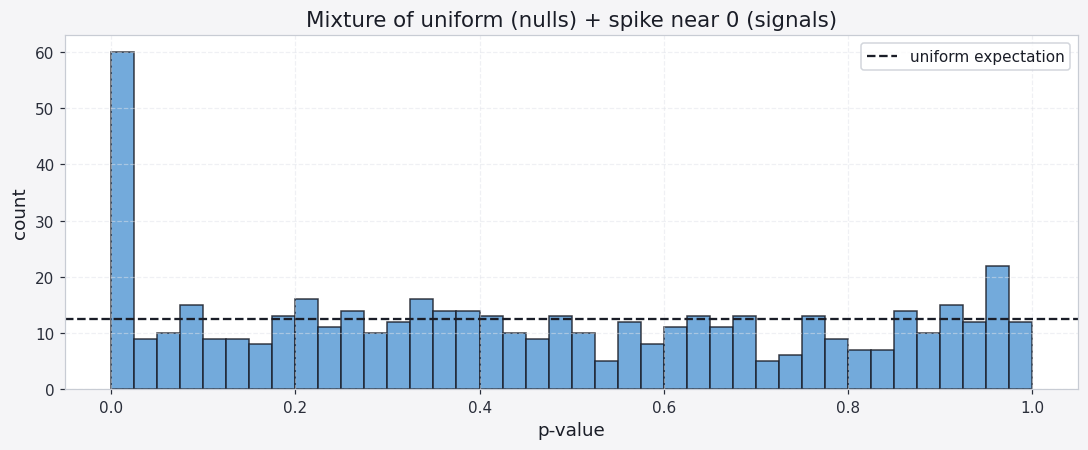

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.hist(pvals, bins=40, color=PALETTE[0], edgecolor='#1a1d27', alpha=0.85)
ax.axhline(m/40, color='#1a1d27', ls='--', lw=1.5, label='uniform expectation')
ax.set_xlabel('p-value'); ax.set_ylabel('count')
ax.set_title('Mixture of uniform (nulls) + spike near 0 (signals)')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


---
## 2. Bonferroni vs Benjamini-Hochberg

- **Bonferroni**: reject if $p_i < \alpha/m$ (very strict; controls FWER).
- **BH**: sort $p_{(1)} \le \dots \le p_{(m)}$ and reject the largest $i$ with $p_{(i)} \le i\alpha/m$ (gentler; controls FDR).


Method            TP   FP   FDR    Power
Raw α=.05         48   21   0.304   0.960
Bonferroni        18    0   0.000   0.360
Benjamini-Hochberg    38    0   0.000   0.760


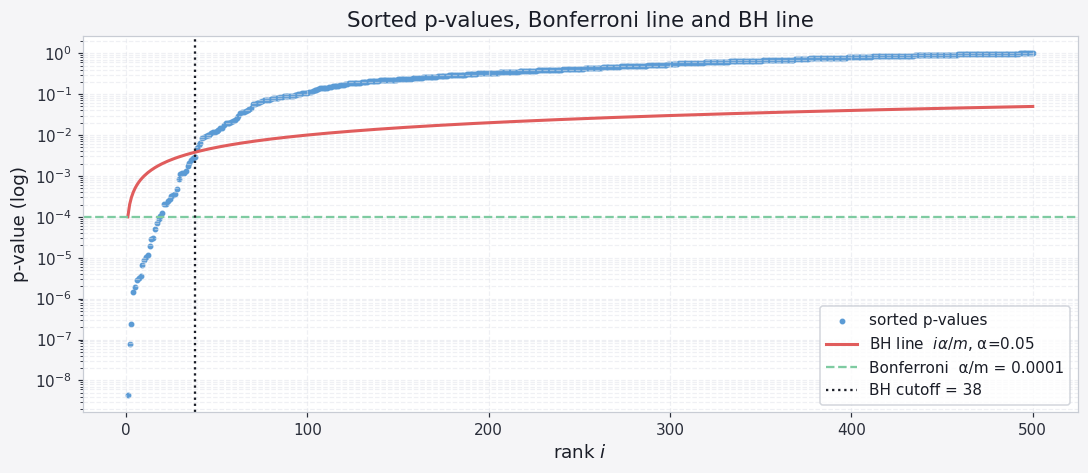

In [4]:
alpha = 0.05

# Bonferroni
bonf_thresh = alpha / m
rej_bonf = pvals < bonf_thresh

# BH
order = np.argsort(pvals)
sorted_p = pvals[order]
bh_line = (np.arange(1, m+1) / m) * alpha
k = np.where(sorted_p <= bh_line)[0]
k_max = k.max() if len(k) else -1
rej_bh = np.zeros(m, dtype=bool)
if k_max >= 0:
    rej_bh[order[:k_max+1]] = True

def confusion(rej):
    TP = (rej &  true_signal).sum()
    FP = (rej & ~true_signal).sum()
    FN = (~rej &  true_signal).sum()
    TN = (~rej & ~true_signal).sum()
    fdr = FP / max(TP + FP, 1)
    pwr = TP / (TP + FN)
    return TP, FP, fdr, pwr

print(f'{"Method":<14}  {"TP":>4} {"FP":>4}   FDR    Power')
for name, r in [('Raw α=.05', pvals < alpha), ('Bonferroni', rej_bonf), ('Benjamini-Hochberg', rej_bh)]:
    tp, fp, fdr, pwr = confusion(r)
    print(f'{name:<14}  {tp:>4} {fp:>4}   {fdr:.3f}   {pwr:.3f}')

# BH visualisation
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.scatter(np.arange(1, m+1), sorted_p, s=8, color=PALETTE[0], label='sorted p-values')
ax.plot(np.arange(1, m+1), bh_line, color=PALETTE[1], lw=2, label=f'BH line  $i\\alpha/m$, α={alpha}')
ax.axhline(bonf_thresh, color=PALETTE[3], ls='--', lw=1.5, label=f'Bonferroni  α/m = {bonf_thresh:.4f}')
if k_max >= 0:
    ax.axvline(k_max+1, color='#1a1d27', ls=':', label=f'BH cutoff = {k_max+1}')
ax.set_yscale('log'); ax.set_xlabel('rank $i$'); ax.set_ylabel('p-value (log)')
ax.set_title('Sorted p-values, Bonferroni line and BH line')
ax.legend(loc='lower right'); ax.grid(True, which='both')
plt.tight_layout(); plt.show()


---
## What we just saw

- **Raw** thresholding rejects far more nulls than signals — uncontrolled FWER.
- **Bonferroni** is conservative: very few false positives, but **misses** many real signals (low power).
- **BH** finds **almost all** real signals while keeping the FDR around the chosen $\alpha$.

> Lesson: when you run many tests, never report raw p-values. Choose Bonferroni when *any* false positive is unacceptable (e.g. confirmatory studies); choose BH when you can tolerate a small fraction of false discoveries (e.g. screening).
